In [2]:
import getpass
import os


def _set_env(key: str):
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f"{key}:")


_set_env("GOOGLE_API_KEY")

GOOGLE_API_KEY: ········


In [4]:
import os
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain.vectorstores import Chroma
from IPython.display import Image, display

In [5]:
# 1. Load PDF
loader = PyPDFLoader("mlintro.pdf")  # ⬅️ your PDF file here
docs = loader.load()

In [6]:
# 2. Split into chunks
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
chunks = splitter.split_documents(docs)

In [7]:
# 3. Create embedding model
embedding = GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")

In [8]:
# 4. Store in Chroma
db = Chroma.from_documents(
    documents=chunks,
    embedding=embedding,
    persist_directory="chroma_db"
)

db.persist()
print("✅ PDF embedded and stored in Chroma DB.")

✅ PDF embedded and stored in Chroma DB.


/var/folders/sm/ffwbnvpd30gg_9jjvnkklqt00000gn/T/ipykernel_11756/3947348838.py:8: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  db.persist()


In [9]:
# Retriever
embedding = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
retriever = Chroma(persist_directory="chroma_db", embedding_function=embedding).as_retriever(search_kwargs={"k": 4})

/var/folders/sm/ffwbnvpd30gg_9jjvnkklqt00000gn/T/ipykernel_11756/3659511832.py:3: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  retriever = Chroma(persist_directory="chroma_db", embedding_function=embedding).as_retriever(search_kwargs={"k": 4})


In [10]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_machine_learning_info",
    "Search and return information about machine learning concepts.",
)

In [11]:
retriever_tool.invoke({"query": "what is a random variable"})

'Fig. 3.1. The convex set (left) contains the line joining any two points that belong\nto the set. A non-convex set (right) does not satisfy this property.\nA vector sum ∑\niλixi is called a convex combination ifλi ≥0 and ∑\niλi =\n1. Convex combinations are helpful in deﬁning a convex hull:\nDeﬁnition 3.2 (Convex Hull) The convex hull, conv(X), of a ﬁnite sub-\nset X = {x1,...,x n}of Rn consists of all convex combinations of x1,...,x n.\n3.1.2 Convex Functions\n\nFig. 3.1. The convex set (left) contains the line joining any two points that belong\nto the set. A non-convex set (right) does not satisfy this property.\nA vector sum ∑\niλixi is called a convex combination ifλi ≥0 and ∑\niλi =\n1. Convex combinations are helpful in deﬁning a convex hull:\nDeﬁnition 3.2 (Convex Hull) The convex hull, conv(X), of a ﬁnite sub-\nset X = {x1,...,x n}of Rn consists of all convex combinations of x1,...,x n.\n3.1.2 Convex Functions\n\nthat the solution J(wt) is ϵ optimum, that is, J(wt) ≤J(w∗) + ϵ

In [12]:
from langgraph.graph import MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI

response_model = ChatGoogleGenerativeAI(model="gemini-2.0-flash-lite")

def generate_query_or_respond(state: MessagesState):
    """Call the model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply respond to the user.
    """
    response = (
        response_model
        .bind_tools([retriever_tool]).invoke(state["messages"])
    )
    return {"messages": [response]}

In [13]:
input = {"messages": [{"role": "user", "content": "hello!"}]}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hello! How can I help you today?


In [15]:
input = {
    "messages": [
        {
            "role": "user",
            "content": "What is a random variable in context of machine learning?",
        }
    ]
}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  retrieve_machine_learning_info (2a57d32f-56c4-451c-aa68-5aa94d935c15)
 Call ID: 2a57d32f-56c4-451c-aa68-5aa94d935c15
  Args:
    query: random variable


In [16]:
from pydantic import BaseModel, Field
from typing import Literal

GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)


class GradeDocuments(BaseModel):
    """Grade documents using a binary score for relevance check."""

    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"
    )


grader_model = ChatGoogleGenerativeAI(model="gemini-2.0-flash-lite")

In [17]:
def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """Determine whether the retrieved documents are relevant to the question."""
    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = (
        grader_model
        .with_structured_output(GradeDocuments).invoke(
            [{"role": "user", "content": prompt}]
        )
    )
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

In [18]:
from langchain_core.messages import convert_to_messages

input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {"role": "tool", "content": "meow", "tool_call_id": "1"},
        ]
    )
}
grade_documents(input)

'rewrite_question'

In [20]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1",
            },
        ]
    )
}
grade_documents(input)

'generate_answer'

In [21]:
REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)


def rewrite_question(state: MessagesState):
    """Rewrite the original user question."""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [{"role": "user", "content": response.content}]}

In [22]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {"role": "tool", "content": "meow", "tool_call_id": "1"},
        ]
    )
}

response = rewrite_question(input)
print(response["messages"][-1]["content"])

Here's an improved question, aiming for more specific and helpful information:

**What types of reward hacking are discussed or described by Lilian Weng in her writings (e.g., blog posts, papers)?**

Here's why this is an improvement:

*   **Specificity:** It narrows the scope to specific writings (blog posts, papers) by Lilian Weng, making it easier to find the relevant information.
*   **Clarity:** "Discussed or described" is more precise than just "says" because it allows for a broader range of information (definitions, examples, analyses).
*   **Focus:** It explicitly asks for the *types* of reward hacking, which is likely the core interest of the original question.
*   **Context:** Adding the phrase, "in her writings" gives context and clues as to where the answer might be found.


In [23]:
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)


def generate_answer(state: MessagesState):
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

In [24]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1",
            },
        ]
    )
}

response = generate_answer(input)
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

Lilian Weng categorizes reward hacking into two types. These are environment or goal misspecification and reward tampering. I hope this helps!


In [27]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

workflow = StateGraph(MessagesState)

# Define the nodes we will cycle between
workflow.add_node(generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retriever_tool]))
workflow.add_node(rewrite_question)
workflow.add_node(generate_answer)

workflow.add_edge(START, "generate_query_or_respond")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "generate_query_or_respond",
    # Assess LLM decision (call `retriever_tool` tool or respond to the user)
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# Compile
graph = workflow.compile()

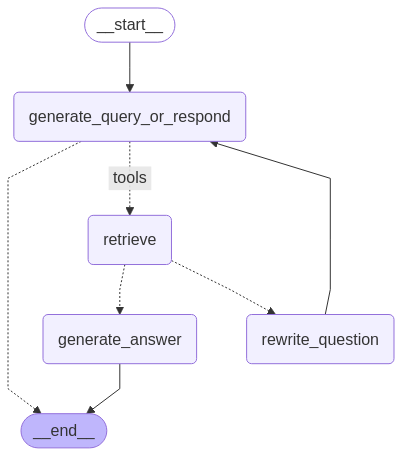

In [28]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
messages = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is a nave bayes",
            }
        ]

    }
)

In [34]:
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is a nave bayes
================================== Ai Message ==================================
Tool Calls:
  retrieve_machine_learning_info (433d2ecc-1925-4b6f-8f7f-b06b68daf9d9)
 Call ID: 433d2ecc-1925-4b6f-8f7f-b06b68daf9d9
  Args:
    query: naive bayes
================================= Tool Message =================================
Name: retrieve_machine_learning_info

Suppose we are given a LP of the form:
min
w
c⊤w (3.116a)
s. t. Aw≥b, (3.116b)
we can transform it into a canonical LP by introducing non-negative slack
variables
min
w,ξ
c⊤w (3.117a)
s. t. Aw−ξ= b,ξ ≥0. (3.117b)
Next, we split w into its positive and negative parts w+ and w− respec-
tively by setting w+
i = max(0,wi) and w−
i = max(0,−wi). Using these new

Suppose we are given a LP of the form:
min
w
c⊤w (3.116a)
s. t. Aw≥b, (3.116b)
we can transform it into a canonical LP by introducing non-negative slack
variables
min
w,ξ
c⊤w 